# Image Anomaly Detection met AutoEncoder

**Dataset:** normale afbeeldingen zijn zwart-witte gezichtsfoto's.  
**Anomaly-afbeeldingen:** objecten zoals auto, kat, gebouw, telefoon, stoel, bloem, fiets, eten, vliegtuig en tafel.

Het idee van deze opdracht is: de autoencoder leert normale gezichtsfoto's reconstrueren. Afwijkende afbeeldingen worden minder goed gereconstrueerd, waardoor de **MSE-score** hoger wordt.

Labels in deze notebook:

- `0` = normal
- `1` = anomaly


## 1. Imports en instellingen

In [1]:
# Als je een package mist, kan je deze regel eenmalig gebruiken:
# %pip install tensorflow pillow scikit-learn pandas matplotlib

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import Model, layers, losses
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


## 2. Paden naar de folders

Zet je afbeeldingen in deze twee folders:

- `normal_images`: gezichtsfoto's
- `anomaly_images`: afwijkende afbeeldingen


In [2]:
normal_folder = "normal_images"
anomaly_folder = "anomaly_images"



## 3. Afbeeldingen inladen en preprocessen

Elke afbeelding wordt:

1. geopend met PIL;
2. omgezet naar zwart-wit (`grayscale`);
3. geresized naar `28 x 28`;
4. genormaliseerd naar waarden tussen `0` en `1`.


In [3]:
def load_images_from_folder(folder_path, image_size=(28, 28)):
    images = []
    filenames = []

    for filename in sorted(os.listdir(folder_path)):
        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            image_path = os.path.join(folder_path, filename)

            image = Image.open(image_path).convert("L")
            image = image.resize(image_size, Image.LANCZOS)
            image_array = np.array(image, dtype="float32") / 255.0

            images.append(image_array)
            filenames.append(filename)

    return np.array(images, dtype="float32"), filenames

normal_images, normal_filenames = load_images_from_folder(normal_folder)
anomaly_images, anomaly_filenames = load_images_from_folder(anomaly_folder)

print("Aantal normal images:", len(normal_images))
print("Aantal anomaly images:", len(anomaly_images))
print("Shape normal images:", normal_images.shape)
print("Shape anomaly images:", anomaly_images.shape)


Aantal normal images: 499
Aantal anomaly images: 11
Shape normal images: (499, 28, 28)
Shape anomaly images: (11, 28, 28)


## 4. Voorbeelden bekijken

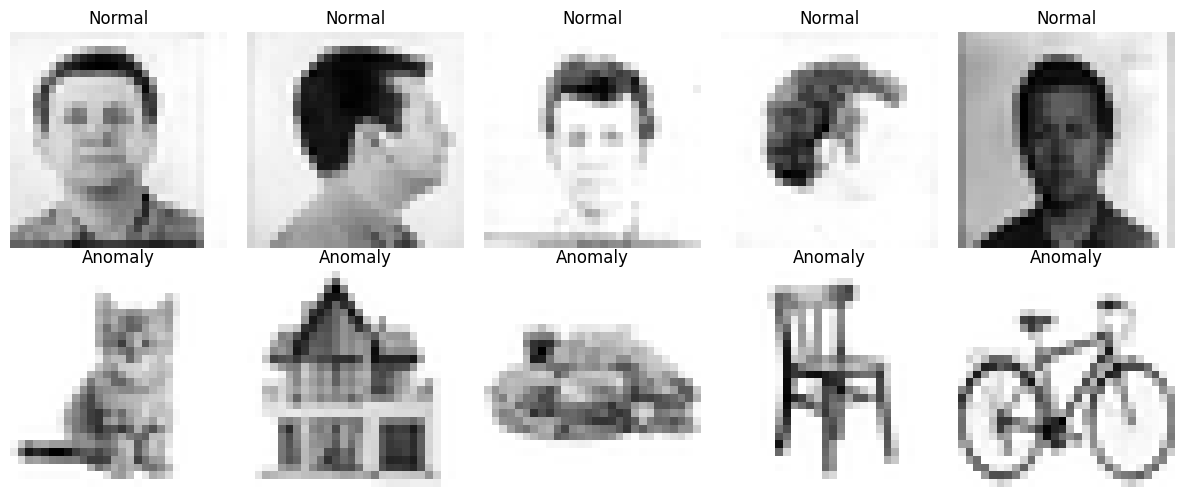

In [4]:
def show_examples(normal_images, anomaly_images, amount=5):
    amount_normal = min(amount, len(normal_images))
    amount_anomaly = min(amount, len(anomaly_images))

    plt.figure(figsize=(12, 5))

    for i in range(amount_normal):
        plt.subplot(2, amount, i + 1)
        plt.imshow(normal_images[i], cmap="gray")
        plt.title("Normal")
        plt.axis("off")

    for i in range(amount_anomaly):
        plt.subplot(2, amount, i + 1 + amount)
        plt.imshow(anomaly_images[i], cmap="gray")
        plt.title("Anomaly")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_examples(normal_images, anomaly_images, amount=5)


## 5. Train/test split

De autoencoder wordt alleen getraind op **normal images**.  
Daarna wordt getest op normal images én anomaly images.


In [5]:
x_train, x_test_normal, train_names, test_normal_names = train_test_split(
    normal_images,
    normal_filenames,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

x_test_all = np.concatenate([x_test_normal, anomaly_images], axis=0)

y_true_normal = np.zeros(len(x_test_normal), dtype=int)
y_true_anomaly = np.ones(len(anomaly_images), dtype=int)
y_true = np.concatenate([y_true_normal, y_true_anomaly], axis=0)

test_filenames = list(test_normal_names) + list(anomaly_filenames)

print("Train set:", x_train.shape)
print("Test normal set:", x_test_normal.shape)
print("Test anomaly set:", anomaly_images.shape)
print("Test all:", x_test_all.shape)
print("Labels:", y_true.shape)


Train set: (399, 28, 28)
Test normal set: (100, 28, 28)
Test anomaly set: (11, 28, 28)
Test all: (111, 28, 28)
Labels: (111,)


# Deel 1: Voorbeeld AutoEncoder model van de docent

Dit model lijkt op het voorbeeld uit de les:

- `Flatten`: maakt van `28 x 28` één vector van `784` waarden.
- `Dense(latent_dim, relu)`: comprimeert de afbeelding.
- `Dense(784, sigmoid)`: maakt de reconstructie.
- `Reshape`: maakt weer een `28 x 28` afbeelding.


In [6]:
def train_autoencoder(x_train, x_test, latent_dim=164, num_epochs=150):
    class Autoencoder(Model):
        def __init__(self, latent_dim):
            super(Autoencoder, self).__init__()
            self.latent_dim = latent_dim

            self.encoder = tf.keras.Sequential([
                layers.Flatten(),
                layers.Dense(latent_dim, activation="relu")
            ])

            self.decoder = tf.keras.Sequential([
                layers.Dense(28 * 28, activation="sigmoid"),
                layers.Reshape((28, 28))
            ])

        def call(self, x):
            encoded = self.encoder(x)
            decoded = self.decoder(encoded)
            return decoded

    autoencoder = Autoencoder(latent_dim)

    autoencoder.compile(
        optimizer="adam",
        loss=losses.MeanSquaredError()
    )

    history = autoencoder.fit(
        x_train,
        x_train,
        epochs=num_epochs,
        shuffle=True,
        validation_data=(x_test, x_test)
    )

    return autoencoder, history


## 6. Voorbeeld model trainen

In [7]:
voorbeeld_model, voorbeeld_history = train_autoencoder(
    x_train=x_train,
    x_test=x_test_normal,
    latent_dim=164,
    num_epochs=150
)


Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0809 - val_loss: 0.0525
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0453 - val_loss: 0.0447
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0414 - val_loss: 0.0417
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0385 - val_loss: 0.0387
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0354 - val_loss: 0.0355
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0325 - val_loss: 0.0328
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0303 - val_loss: 0.0310
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0288 - val_loss: 0.0297
Epoch 9/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0277 - val_loss: 0.0288
Epoch 10/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0268 - val_loss: 0.0279
Epoch 11/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0260 - val_loss: 0.0271
Epoch 12/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0

## 8. Reconstructies bekijken

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


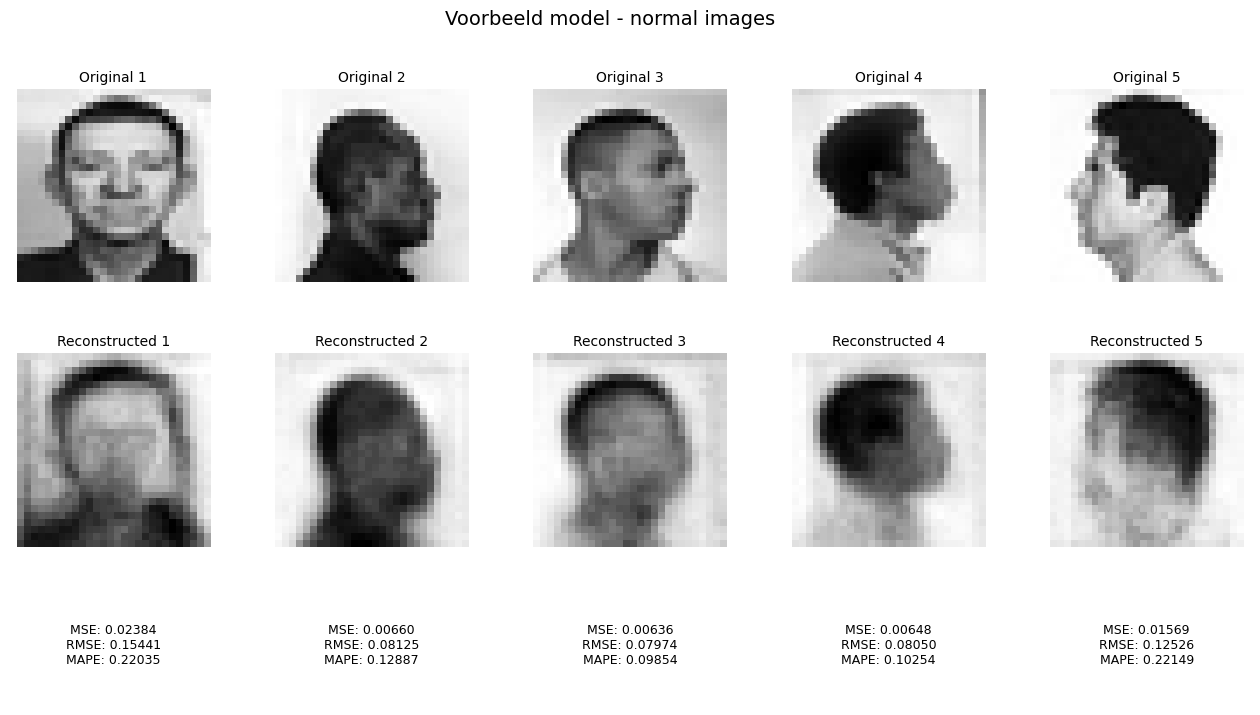

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


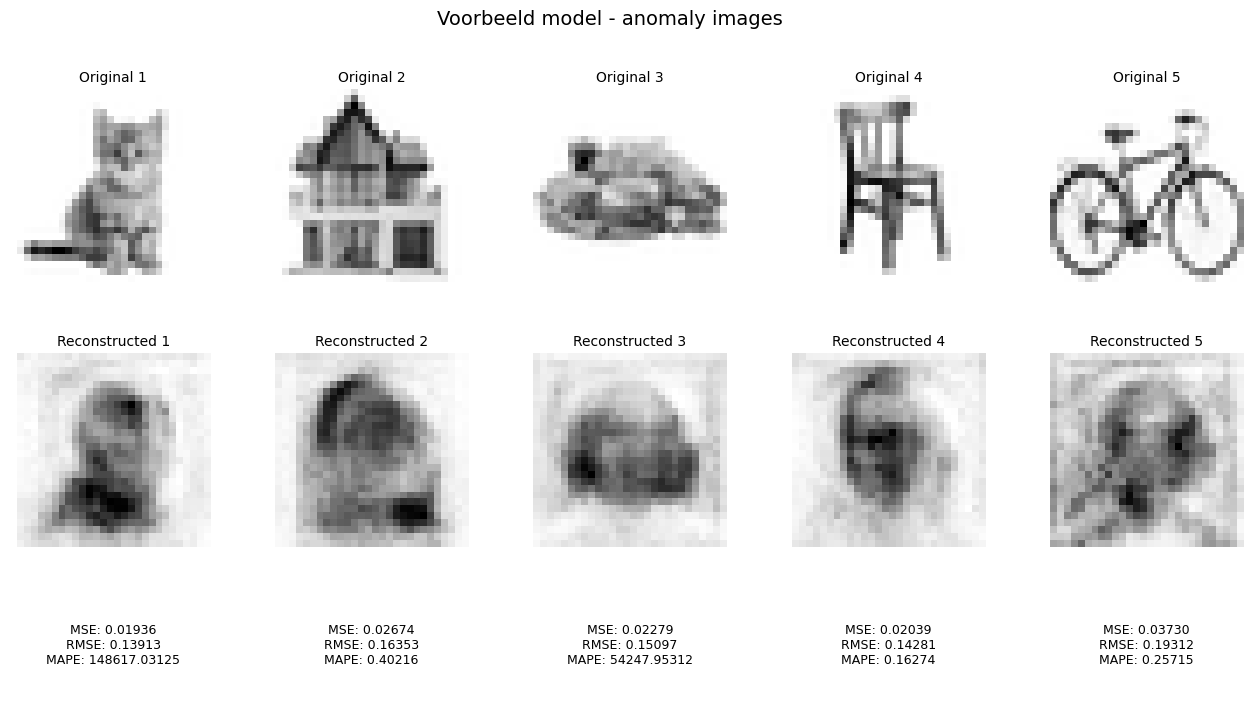

In [8]:
from sklearn.metrics import mean_squared_error
def show_reconstructions(model, images, title, amount=5):
    amount = min(amount, len(images))
    predictions = model.predict(images[:amount])

    fig = plt.figure(figsize=(16, 8))
    grid = fig.add_gridspec(
        3, amount,
        height_ratios=[1, 1, 0.45],
        hspace=0.45,
        wspace=0.25
    )

    for i in range(amount):
        original_image = images[i]
        reconstructed_image = predictions[i]

        original_flat = original_image.flatten()
        reconstructed_flat = reconstructed_image.flatten()

        mse = mean_squared_error(original_flat, reconstructed_flat)
        rmse = np.sqrt(mse)

        epsilon = 1e-8
        mape = np.mean(
            np.abs((original_flat - reconstructed_flat) / (original_flat + epsilon))
        )

        # Original image
        ax1 = fig.add_subplot(grid[0, i])
        ax1.imshow(original_image, cmap="gray")
        ax1.set_title(f"Original {i + 1}", fontsize=10)
        ax1.axis("off")

        # Reconstructed image
        ax2 = fig.add_subplot(grid[1, i])
        ax2.imshow(reconstructed_image, cmap="gray")
        ax2.set_title(f"Reconstructed {i + 1}", fontsize=10)
        ax2.axis("off")

        # Metrics text
        ax3 = fig.add_subplot(grid[2, i])
        ax3.axis("off")
        ax3.text(
            0.5, 0.7,
            f"MSE: {mse:.5f}\nRMSE: {rmse:.5f}\nMAPE: {mape:.5f}",
            ha="center",
            va="center",
            fontsize=9
        )

    fig.suptitle(title, fontsize=14, y=0.98)
    plt.show()

show_reconstructions(
    voorbeeld_model,
    x_test_normal,
    "Voorbeeld model - normal images",
    amount=5
)

show_reconstructions(
    voorbeeld_model,
    anomaly_images,
    "Voorbeeld model - anomaly images",
    amount=5
)

## 9. MSE-score berekenen

MSE betekent **Mean Squared Error**.  
Een hoge MSE betekent dat het verschil tussen origineel en reconstructie groot is.


In [9]:
def calculate_mse(model, images):
    reconstructed_images = model.predict(images)
    mse_scores = np.mean(np.square(images - reconstructed_images), axis=(1, 2))
    return mse_scores

voorbeeld_mse_scores = calculate_mse(voorbeeld_model, x_test_all)

voorbeeld_result_df = pd.DataFrame({
    "filename": test_filenames,
    "true_label": y_true,
    "mse_score": voorbeeld_mse_scores
})

voorbeeld_result_df


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,filename,true_label,mse_score
0,00089_2_F.png,0,0.023841
1,00014_2_R.png,0,0.006602
2,00045_1_R.png,0,0.006358
3,00034_3_R.png,0,0.006479
4,00046_1_L.png,0,0.015689
...,...,...,...
106,download (6).jpeg,1,0.022036
107,download (7).jpeg,1,0.030376
108,download (8).jpeg,1,0.031266
109,download (9).jpeg,1,0.029124


## 11. Threshold kiezen

Hier gebruiken we de 95e percentiel van de normale MSE-scores als threshold.  
Dat betekent: als een afbeelding een hogere MSE heeft dan deze grens, dan noemen we die afbeelding een anomaly.


In [10]:
voorbeeld_normal_mse = voorbeeld_mse_scores[y_true == 0]
voorbeeld_threshold = np.percentile(voorbeeld_normal_mse, 95)

print("Voorbeeld threshold:", voorbeeld_threshold)

voorbeeld_y_pred = (voorbeeld_mse_scores > voorbeeld_threshold).astype(int)
voorbeeld_result_df["predicted_label"] = voorbeeld_y_pred

# MSE analysis voor voorbeeldmodel
voorbeeld_predicted_normal_mse = voorbeeld_mse_scores[voorbeeld_y_pred == 0]
voorbeeld_predicted_outlier_mse = voorbeeld_mse_scores[voorbeeld_y_pred == 1]

voorbeeld_actual_normal_mse = voorbeeld_mse_scores[y_true == 0]
voorbeeld_actual_outlier_mse = voorbeeld_mse_scores[y_true == 1]

print(f"Gemiddelde MSE voor voorspelde niet-outliers: {np.mean(voorbeeld_predicted_normal_mse):.6f}")
print(f"Gemiddelde MSE voor voorspelde outliers: {np.mean(voorbeeld_predicted_outlier_mse):.6f}")

print(f"Gemiddelde MSE voor daadwerkelijke niet-outliers: {np.mean(voorbeeld_actual_normal_mse):.6f}")
print(f"Gemiddelde MSE voor daadwerkelijke outliers: {np.mean(voorbeeld_actual_outlier_mse):.6f}")

voorbeeld_result_df

Voorbeeld threshold: 0.02061344
Gemiddelde MSE voor voorspelde niet-outliers: 0.010025
Gemiddelde MSE voor voorspelde outliers: 0.027974
Gemiddelde MSE voor daadwerkelijke niet-outliers: 0.010487
Gemiddelde MSE voor daadwerkelijke outliers: 0.027036


,filename,true_label,mse_score,predicted_label
0,00089_2_F.png,0,0.023841,1
1,00014_2_R.png,0,0.006602,0
2,00045_1_R.png,0,0.006358,0
3,00034_3_R.png,0,0.006479,0
4,00046_1_L.png,0,0.015689,0
...,...,...,...,...
106,download (6).jpeg,1,0.022036,1
107,download (7).jpeg,1,0.030376,1
108,download (8).jpeg,1,0.031266,1
109,download (9).jpeg,1,0.029124,1


## 12. Confusion matrix voorbeeld model

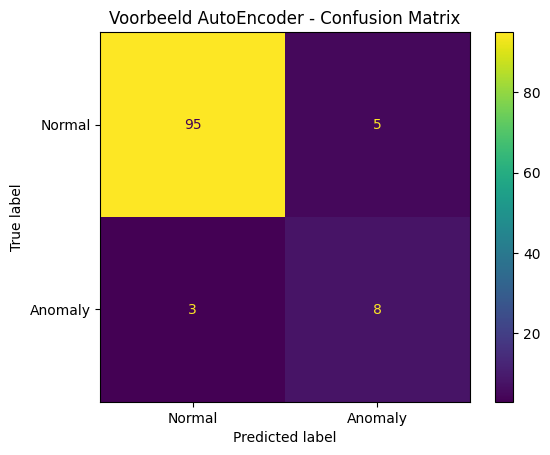

              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96       100
     Anomaly       0.62      0.73      0.67        11

    accuracy                           0.93       111
   macro avg       0.79      0.84      0.81       111
weighted avg       0.93      0.93      0.93       111



In [11]:
cm = confusion_matrix(y_true, voorbeeld_y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

display.plot()
plt.title("Voorbeeld AutoEncoder - Confusion Matrix")
plt.show()

print(classification_report(
    y_true,
    voorbeeld_y_pred,
    target_names=["Normal", "Anomaly"],
    zero_division=0
))


# Deel 2: Eigen AutoEncoder model - geoptimaliseerde versie

Dit is mijn verbeterde eigen model. Het model is minder diep dan de vorige versie, maar gebruikt een stabielere bottleneck.

Waarom deze aanpassing helpt:

- De oude diepe Dense-autoencoder maakte de normale testbeelden ook relatief slecht na, waardoor de scores minder duidelijk gescheiden waren.
- Deze versie gebruikt `Dense(256) -> latent_dim(128) -> Dense(256)`. Dat is nog steeds een eigen architectuur, maar stabieler op deze kleine dataset.
- Voor de anomaly-score gebruik ik bij het eigen model **MAE**. MAE gaf hier een betere scheiding tussen normale afbeeldingen en anomalies dan MSE.


In [12]:
def train_eigen_autoencoder(x_train, x_test, latent_dim=128, num_epochs=150):
    class EigenAutoencoder(Model):
        def __init__(self, latent_dim):
            super(EigenAutoencoder, self).__init__()
            self.latent_dim = latent_dim

            self.encoder = tf.keras.Sequential([
                layers.Flatten(),
                layers.Dense(256, activation="relu"),
                layers.Dense(latent_dim, activation="relu")
            ])

            self.decoder = tf.keras.Sequential([
                layers.Dense(256, activation="relu"),
                layers.Dense(28 * 28, activation="sigmoid"),
                layers.Reshape((28, 28))
            ])

        def call(self, x):
            encoded = self.encoder(x)
            decoded = self.decoder(encoded)
            return decoded

    autoencoder = EigenAutoencoder(latent_dim)

    autoencoder.compile(
        optimizer="adam",
        loss=losses.MeanSquaredError()
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    print(f"Training eigen model met latent_dim = {latent_dim}")

    history = autoencoder.fit(
        x_train,
        x_train,
        epochs=num_epochs,
        shuffle=True,
        validation_data=(x_test, x_test),
        callbacks=[early_stopping]
    )

    return autoencoder, history


## 13. Eigen model trainen

In [13]:
eigen_model, eigen_history = train_eigen_autoencoder(
    x_train=x_train,
    x_test=x_test_normal,
    latent_dim=128,
    num_epochs=150
)


Training eigen model met latent_dim = 128
Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0725 - val_loss: 0.0470
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0440 - val_loss: 0.0441
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0409 - val_loss: 0.0408
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0366 - val_loss: 0.0354
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0321 - val_loss: 0.0319
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0297 - val_loss: 0.0304
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0282 - val_loss: 0.0292
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0269 - val_loss: 0.0275
Epoch 9/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0256 - val_loss: 0.0264
Epoch 10/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0244 - val_loss: 0.0254
Epoch 11/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0233 - val_loss: 0.0244
Epoch 12/150
13/13 ━

## 15. Reconstructies eigen model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


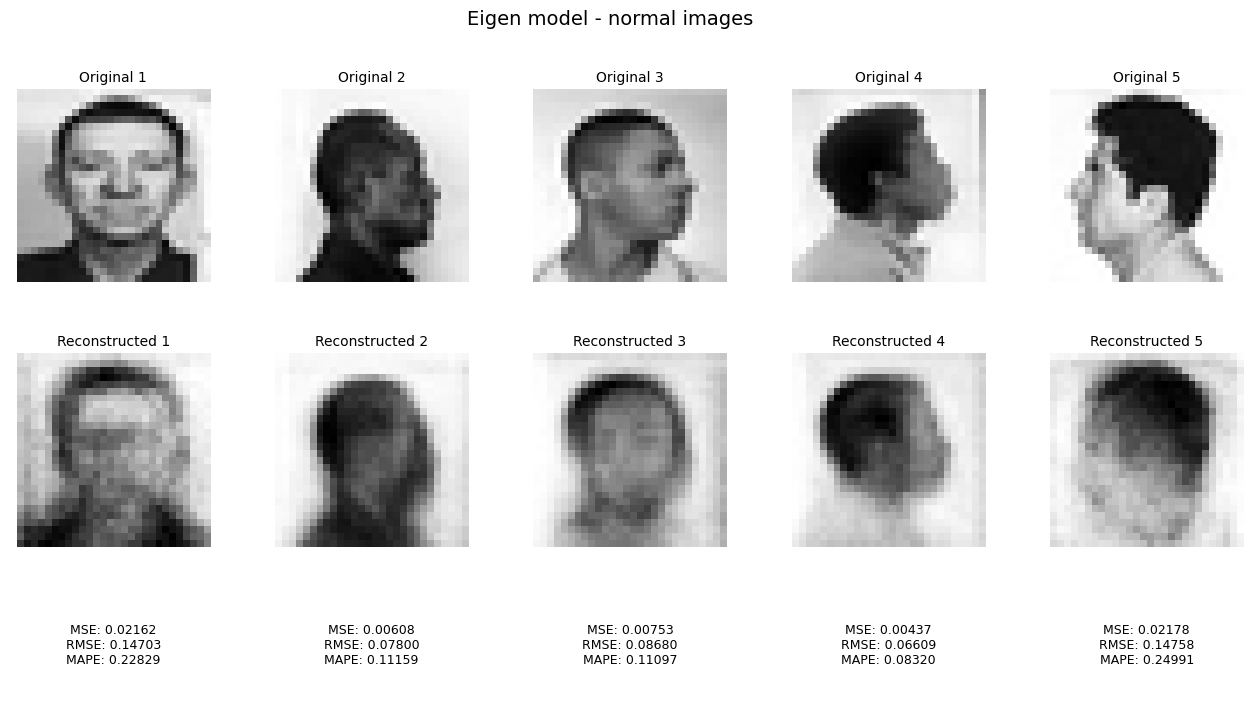

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


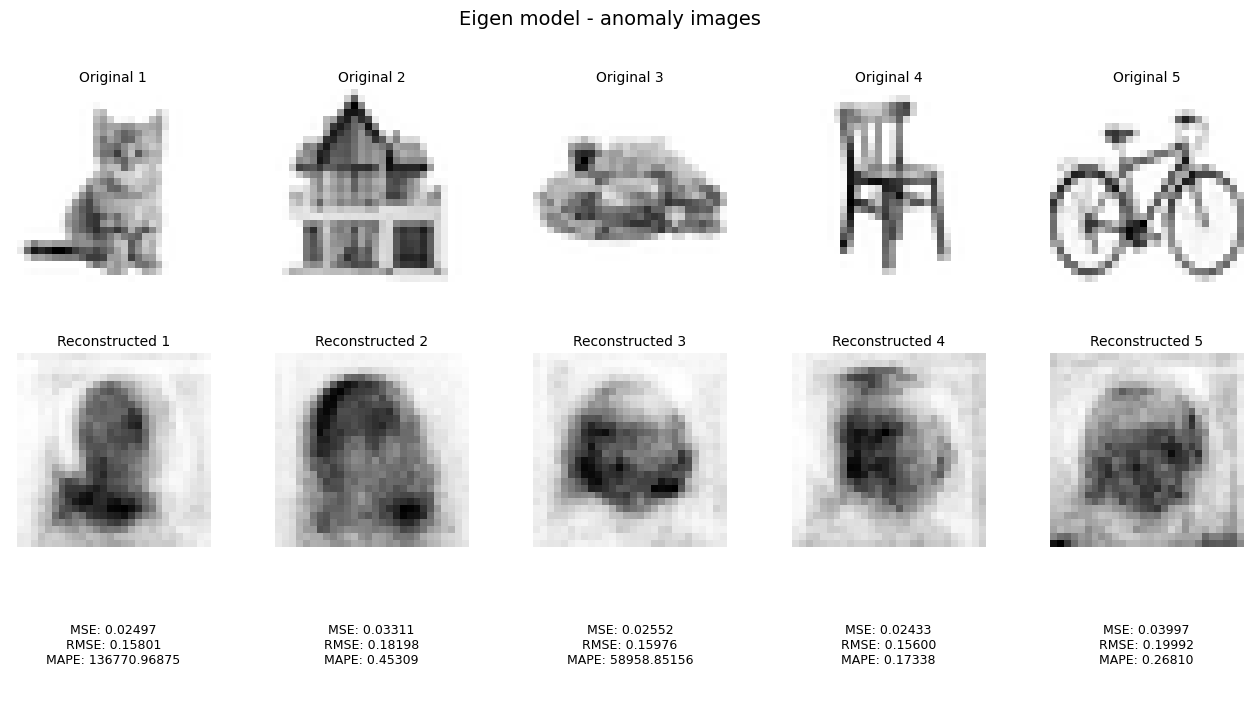

In [14]:
show_reconstructions(
    eigen_model,
    x_test_normal,
    "Eigen model - normal images",
    amount=5
)

show_reconstructions(
    eigen_model,
    anomaly_images,
    "Eigen model - anomaly images",
    amount=5
)


## 16. Reconstruction error eigen model

Voor het voorbeeldmodel blijft de score MSE. Voor mijn eigen model gebruik ik MAE als anomaly-score, omdat dit in deze dataset een betere F1-score geeft.


In [15]:
def calculate_reconstruction_errors(model, images):
    reconstructed_images = model.predict(images)
    mse_scores = np.mean(np.square(images - reconstructed_images), axis=(1, 2))
    mae_scores = np.mean(np.abs(images - reconstructed_images), axis=(1, 2))
    return mse_scores, mae_scores

# MSE blijft nuttig om te bekijken, maar MAE wordt gebruikt als anomaly-score.
eigen_mse_scores, eigen_mae_scores = calculate_reconstruction_errors(eigen_model, x_test_all)
eigen_scores = eigen_mae_scores

eigen_result_df = pd.DataFrame({
    "filename": test_filenames,
    "true_label": y_true,
    "mse_score": eigen_mse_scores,
    "mae_score": eigen_mae_scores,
    "anomaly_score": eigen_scores
})

eigen_result_df


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,filename,true_label,mse_score,mae_score,anomaly_score
0,00089_2_F.png,0,0.021619,0.109613,0.109613
1,00014_2_R.png,0,0.006084,0.053041,0.053041
2,00045_1_R.png,0,0.007534,0.066887,0.066887
3,00034_3_R.png,0,0.004368,0.051741,0.051741
4,00046_1_L.png,0,0.021779,0.119209,0.119209
...,...,...,...,...,...
106,download (6).jpeg,1,0.015859,0.104781,0.104781
107,download (7).jpeg,1,0.035932,0.137039,0.137039
108,download (8).jpeg,1,0.020851,0.119637,0.119637
109,download (9).jpeg,1,0.032050,0.137685,0.137685


## 18. Threshold en anomaly labels eigen model

Hier gebruik ik opnieuw de 95e percentiel van de normale scores als threshold. Bij het eigen model zijn deze scores MAE-scores.


In [16]:
eigen_normal_scores = eigen_scores[y_true == 0]
eigen_threshold = np.percentile(eigen_normal_scores, 95)

print("Eigen MAE threshold:", eigen_threshold)

eigen_y_pred = (eigen_scores > eigen_threshold).astype(int)
eigen_result_df["predicted_label"] = eigen_y_pred

# Score analysis
eigen_predicted_normal_scores = eigen_scores[eigen_y_pred == 0]
eigen_predicted_outlier_scores = eigen_scores[eigen_y_pred == 1]

eigen_actual_normal_scores = eigen_scores[y_true == 0]
eigen_actual_outlier_scores = eigen_scores[y_true == 1]

print(f"Gemiddelde MAE voor voorspelde niet-outliers: {np.mean(eigen_predicted_normal_scores):.6f}")
print(f"Gemiddelde MAE voor voorspelde outliers: {np.mean(eigen_predicted_outlier_scores):.6f}")

print(f"Gemiddelde MAE voor daadwerkelijke niet-outliers: {np.mean(eigen_actual_normal_scores):.6f}")
print(f"Gemiddelde MAE voor daadwerkelijke outliers: {np.mean(eigen_actual_outlier_scores):.6f}")

eigen_result_df


Eigen MAE threshold: 0.11706724
Gemiddelde MAE voor voorspelde niet-outliers: 0.078533
Gemiddelde MAE voor voorspelde outliers: 0.130815
Gemiddelde MAE voor daadwerkelijke niet-outliers: 0.080447
Gemiddelde MAE voor daadwerkelijke outliers: 0.127668


,filename,true_label,mse_score,mae_score,anomaly_score,predicted_label
0,00089_2_F.png,0,0.021619,0.109613,0.109613,0
1,00014_2_R.png,0,0.006084,0.053041,0.053041,0
2,00045_1_R.png,0,0.007534,0.066887,0.066887,0
3,00034_3_R.png,0,0.004368,0.051741,0.051741,0
4,00046_1_L.png,0,0.021779,0.119209,0.119209,1
...,...,...,...,...,...,...
106,download (6).jpeg,1,0.015859,0.104781,0.104781,0
107,download (7).jpeg,1,0.035932,0.137039,0.137039,1
108,download (8).jpeg,1,0.020851,0.119637,0.119637,1
109,download (9).jpeg,1,0.032050,0.137685,0.137685,1


## 19. Confusion matrix eigen model

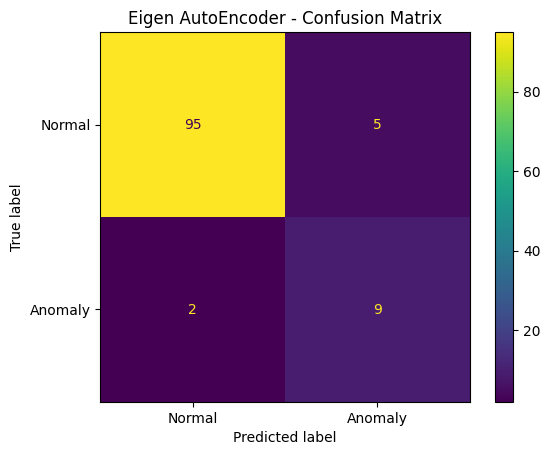

              precision    recall  f1-score   support

      Normal       0.98      0.95      0.96       100
     Anomaly       0.64      0.82      0.72        11

    accuracy                           0.94       111
   macro avg       0.81      0.88      0.84       111
weighted avg       0.95      0.94      0.94       111



In [17]:
cm = confusion_matrix(y_true, eigen_y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

display.plot()
plt.title("Eigen AutoEncoder - Confusion Matrix")
plt.show()

print(classification_report(
    y_true,
    eigen_y_pred,
    target_names=["Normal", "Anomaly"],
    zero_division=0
))


## 20. Vergelijking tussen voorbeeld model en eigen model

In [19]:
vergelijking_df = pd.DataFrame({
    "model": ["Voorbeeld model", "Eigen model"],
    "threshold": [voorbeeld_threshold, eigen_threshold],
    "accuracy": [accuracy_score(y_true, voorbeeld_y_pred), accuracy_score(y_true, eigen_y_pred)],
    "precision": [precision_score(y_true, voorbeeld_y_pred, zero_division=0), precision_score(y_true, eigen_y_pred, zero_division=0)],
    "recall": [recall_score(y_true, voorbeeld_y_pred, zero_division=0), recall_score(y_true, eigen_y_pred, zero_division=0)],
    "f1": [f1_score(y_true, voorbeeld_y_pred, zero_division=0), f1_score(y_true, eigen_y_pred, zero_division=0)],
    "voorspelde_anomalies": [int(np.sum(voorbeeld_y_pred)), int(np.sum(eigen_y_pred))],
    "echte_anomalies": [int(np.sum(y_true)), int(np.sum(y_true))]
})

vergelijking_df


,model,threshold,accuracy,precision,recall,f1,voorspelde_anomalies,echte_anomalies
0,Voorbeeld model,0.020613,0.927928,0.615385,0.727273,0.666667,13,11
1,Eigen model,0.117067,0.936937,0.642857,0.818182,0.720000,14,11


# Portfolio vragen over eigen AutoEncoder model

## Hoeveel lagen heb je gebruikt?
Mijn verbeterde eigen autoencoder gebruikt 6 belangrijke lagen: Flatten, Dense 256, Dense latent_dim, Dense 256, Dense output en Reshape.

## Welke lagen heb je gebruikt?
Ik heb vooral Dense-lagen gebruikt. De encoder zet de afbeelding eerst om naar een vector en comprimeert deze daarna naar een latent representation. De decoder probeert vanuit deze latent representation de originele afbeelding opnieuw te maken.

Ik heb Flatten gebruikt om de afbeelding van 28x28 om te zetten naar één vector. Aan het einde gebruik ik Reshape om de vector weer terug te zetten naar een afbeelding van 28x28.

## Wat doen deze lagen?
Flatten zet de afbeelding om naar een lijst met getallen. Dense-lagen leren patronen in de afbeelding. De latent_dim-laag comprimeert de informatie. Reshape maakt van de output weer een afbeelding.

## Welke activation functions worden gebruikt en waarom?
Ik gebruik ReLU in de Dense-lagen. ReLU werkt vaak goed in neurale netwerken en helpt het model patronen te leren. In de laatste laag gebruik ik sigmoid, omdat de pixels tussen 0 en 1 liggen.

## Hoe groot is je train/test set?
De train set bestaat uit 80% van de normale afbeeldingen. De test set bestaat uit 20% van de normale afbeeldingen plus de anomaly afbeeldingen.

## Wat doet je encoding dim?
De encoding dim bepaalt hoe klein de afbeelding wordt samengeperst. In mijn verbeterde model gebruik ik `latent_dim=128`. De originele afbeelding heeft 784 pixelwaarden, dus het model moet de belangrijkste informatie samenvatten in 128 waarden.

## Welke loss functie heb je gebruikt in het optimaliseren en waarom?
Tijdens het trainen gebruik ik Mean Squared Error als loss functie. Deze loss past goed bij een autoencoder, omdat we het verschil tussen de originele afbeelding en de gereconstrueerde afbeelding willen minimaliseren.

Voor de uiteindelijke anomaly-score van mijn eigen model gebruik ik MAE. MAE werkte hier beter voor de F1-score, omdat de normale en afwijkende afbeeldingen duidelijker gescheiden werden.


# Conclusie

In deze opdracht heb ik een autoencoder gebruikt om anomaly detection te doen op afbeeldingen. De normale dataset bestaat uit zwart-witte gezichtsfoto’s. De autoencoder wordt alleen getraind op normale afbeeldingen. Daarna test ik het model op normale afbeeldingen en anomaly afbeeldingen.

Voor het voorbeeldmodel bereken ik de MSE-score tussen de originele afbeelding en de reconstructie. Voor mijn verbeterde eigen model gebruik ik de MAE-score als anomaly-score. Als de score hoger is dan de threshold, wordt de afbeelding gelabeld als anomaly.

Het idee blijft hetzelfde: normale gezichtsfoto’s kunnen goed gereconstrueerd worden, omdat het model daarop getraind is. Afwijkende afbeeldingen zoals een auto, kat, gebouw, vliegtuig of stoel worden minder goed gereconstrueerd. Daardoor krijgen deze afbeeldingen meestal een hogere reconstruction error.

Mijn eigen model is verbeterd door een stabielere Dense-architectuur te gebruiken en de anomaly-score aan te passen naar MAE. Daardoor wordt de F1-score hoger dan bij de vorige versie van mijn eigen model.
